In [5]:
# Install all dependencies
!pip install -q python-arango sentence-transformers openai google-generativeai spacy tqdm

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Verify files are accessible
import os
DATA_DIR = "/content/drive/MyDrive/691FinalProject/data"
print("Files found:", os.listdir(DATA_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files found: ['dev_test_singlehop_questions_v1.0.json', 'musique_ans_v1.0_dev.jsonl']


In [6]:
# ── ArangoDB ──────────────────────────────────────────
ARANGO_HOST     = "YOUR_ARANGODB_HOST_URL"
ARANGO_USER     = "root"
ARANGO_PASSWORD = "YOUR_ARANGODB_PASSWORD"
ARANGO_DB_NAME  = "graphrag691"

# ── API ──────────────
# Option A: Gemini (free)
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
LLM_BACKEND     = "gemini"

# Option B: OpenAI (~$1-3)
# OPENAI_API_KEY = "YOUR_OPENAI_KEY_HERE"
# LLM_BACKEND    = "openai"

# ── Paths ─────────────────────────────────────────────
MUSIQUE_PATH    = f"{DATA_DIR}/musique_ans_v1.0_dev.jsonl"
SINGLEHOP_PATH  = f"{DATA_DIR}/dev_test_singlehop_questions_v1.0.json"

# ── Experiment settings ────────────────────────────────
N_QUESTIONS     = 300     # total eval questions (can reduce to 100 for speed)
EMB_MODEL       = "BAAI/bge-small-en-v1.5"  # 384-dim, free, fast on GPU
EMB_DIM         = 384
TOP_K           = 5       # passages to retrieve

print("Config set. Backend:", LLM_BACKEND)

Config set. Backend: gemini


In [7]:
from arango import ArangoClient

client  = ArangoClient(hosts=ARANGO_HOST)
sys_db  = client.db("_system", username=ARANGO_USER, password=ARANGO_PASSWORD)

# Create database (skip if exists)
if not sys_db.has_database(ARANGO_DB_NAME):
    sys_db.create_database(ARANGO_DB_NAME)
    print(f"Created database: {ARANGO_DB_NAME}")

db = client.db(ARANGO_DB_NAME, username=ARANGO_USER, password=ARANGO_PASSWORD)

# Document collections
for col in ["paragraphs", "entities"]:
    if not db.has_collection(col):
        db.create_collection(col)
        print(f"Created collection: {col}")

# Edge collections
for col in ["triples", "para_mentions"]:
    if not db.has_collection(col):
        db.create_collection(col, edge=True)
        print(f"Created edge collection: {col}")

# ✅ No vector index needed — we'll use numpy cosine similarity
# ArangoDB handles graph traversal; Python handles vector search in-memory
# For ~3000 paragraphs this is milliseconds per query

print("✅ ArangoDB ready:", db.name)

✅ ArangoDB ready: graphrag691


In [8]:
import json, random
from collections import defaultdict

random.seed(42)

# Load all answerable questions
questions = []
with open(MUSIQUE_PATH) as f:
    for line in f:
        q = json.loads(line)
        if q.get("answerable", True):
            q["hop_count"] = len(q["question_decomposition"])
            questions.append(q)

print(f"Total answerable questions: {len(questions)}")

# Show hop distribution
hop_dist = defaultdict(int)
for q in questions:
    hop_dist[q["hop_count"]] += 1
print("Hop distribution:", dict(sorted(hop_dist.items())))

# Stratified sample: proportional but capped at N_QUESTIONS
sampled = []
for hop in sorted(hop_dist.keys()):
    pool = [q for q in questions if q["hop_count"] == hop]
    n = min(len(pool), int(N_QUESTIONS * hop_dist[hop] / len(questions)) + 1)
    sampled.extend(random.sample(pool, n))

# Trim to exactly N_QUESTIONS
random.shuffle(sampled)
sampled = sampled[:N_QUESTIONS]

print(f"\n✅ Sampled {len(sampled)} questions")
hop_sample_dist = defaultdict(int)
for q in sampled:
    hop_sample_dist[q["hop_count"]] += 1
print("Sample hop distribution:", dict(sorted(hop_sample_dist.items())))

# Extract unique paragraphs across all sampled questions
para_map = {}   # key: (title, text) → paragraph dict
for q in sampled:
    for p in q["paragraphs"]:
        key = (p["title"], p["paragraph_text"])
        if key not in para_map:
            para_map[key] = {
                "_key": f"p{len(para_map)}",
                "title": p["title"],
                "text": p["paragraph_text"],
            }
        # tag if supporting
        if p.get("is_supporting"):
            para_map[key]["is_supporting"] = True

paragraphs = list(para_map.values())
print(f"Unique paragraphs: {len(paragraphs)}")

Total answerable questions: 2417
Hop distribution: {2: 1252, 3: 760, 4: 405}

✅ Sampled 300 questions
Sample hop distribution: {2: 155, 3: 94, 4: 51}
Unique paragraphs: 4685


In [9]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load model (downloads ~33MB, fast on L4)
print("Loading embedding model...")
embedder = SentenceTransformer(EMB_MODEL, device="cuda")
print(f"Model loaded. Dim: {embedder.get_sentence_embedding_dimension()}")

# Compute embeddings (normalize=True makes dot product = cosine similarity)
texts = [p["text"] for p in paragraphs]
print(f"Embedding {len(texts)} paragraphs...")

all_embeddings = embedder.encode(
    texts,
    batch_size=128,
    show_progress_bar=True,
    normalize_embeddings=True
)
print(f"Shape: {all_embeddings.shape}")

# Attach embeddings to paragraph dicts
for i, p in enumerate(paragraphs):
    p["embedding"] = all_embeddings[i].tolist()

# Insert into ArangoDB
para_col = db.collection("paragraphs")
para_col.truncate()  # clear if re-running

for i in range(0, len(paragraphs), 500):
    batch = paragraphs[i:i+500]
    para_col.insert_many(batch, silent=True)
    print(f"  Inserted {min(i+500, len(paragraphs))}/{len(paragraphs)}")

print(f"ArangoDB has {para_col.count()} paragraphs")

# In-memory index for fast vector search (no DB round-trips needed)
PARA_KEYS   = [p["_key"] for p in paragraphs]
PARA_MATRIX = all_embeddings          # shape (4685, 384), normalized
PARA_DICT   = {p["_key"]: p for p in paragraphs}  # key → full doc
print(f"In-memory index ready: {PARA_MATRIX.shape}")

Loading embedding model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded. Dim: 384
Embedding 4685 paragraphs...


/tmp/ipykernel_16128/2347750817.py:7: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded. Dim: {embedder.get_sentence_embedding_dimension()}")


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Shape: (4685, 384)
  Inserted 500/4685
  Inserted 1000/4685
  Inserted 1500/4685
  Inserted 2000/4685
  Inserted 2500/4685
  Inserted 3000/4685
  Inserted 3500/4685
  Inserted 4000/4685
  Inserted 4500/4685
  Inserted 4685/4685
ArangoDB has 4685 paragraphs
In-memory index ready: (4685, 384)


In [10]:
def vector_retrieve(question: str, k: int = TOP_K) -> list[dict]:
    """Cosine similarity retrieval over in-memory numpy matrix."""
    q_emb = embedder.encode([question], normalize_embeddings=True)[0]
    scores = PARA_MATRIX @ q_emb          # dot product = cosine (vectors normalized)
    top_idx = np.argsort(scores)[::-1][:k]
    return [
        {
            "key":   PARA_KEYS[i],
            "title": PARA_DICT[PARA_KEYS[i]]["title"],
            "text":  PARA_DICT[PARA_KEYS[i]]["text"],
            "score": float(scores[i])
        }
        for i in top_idx
    ]

# Smoke test on first question
q0 = sampled[0]
print("Question :", q0["question"])
print("Answer   :", q0["answer"])
print("Hops     :", q0["hop_count"])
print()

retrieved = vector_retrieve(q0["question"])
gold_titles = {p["title"] for p in q0["paragraphs"] if p["is_supporting"]}
print(f"Gold supporting paragraphs: {gold_titles}")
print()
for r in retrieved:
    hit = "Done" if r["title"] in gold_titles else "  "
    print(f"{hit} [{r['score']:.3f}] {r['title']}: {r['text'][:80]}...")

Question : Which professional sports team does not play their home games at the same location where the Amateur Boxing Golden Gloves event is held?
Answer   : Brooklyn Nets NBA
Hops     : 2

Gold supporting paragraphs: {'New York City', 'Sports in the New York metropolitan area'}

   [0.690] Washington Capitals: The Washington Capitals are a professional ice hockey team based in Washington, ...
   [0.678] Green Bay Packers: The Green Bay Packers is a professional American football team based in Green Ba...
Done [0.677] New York City: The annual United States Open Tennis Championships is one of the world's four Gr...
   [0.665] Chicago Cubs: The Chicago Cubs are an American professional baseball team based in Chicago, Il...
   [0.655] Sacramento Kings: The Sacramento Kings are an American professional basketball team based in Sacra...


In [11]:
import spacy, hashlib
from tqdm import tqdm
from collections import defaultdict

nlp = spacy.load("en_core_web_sm")

KEEP_TYPES = {"PERSON","ORG","GPE","LOC","EVENT","WORK_OF_ART","FAC","NORP","PRODUCT"}

def norm(name): return name.lower().strip()
def ent_key(name): return "e" + hashlib.md5(norm(name).encode()).hexdigest()[:12]

def extract_entities(text):
    doc = nlp(text)
    return list({ent.text.strip() for ent in doc.ents
                 if ent.label_ in KEEP_TYPES and len(ent.text.strip()) > 1})

# ── Build graph structures ─────────────────────────────
entity_store   = {}   # normalized → {_key, name, normalized}
triple_docs    = []
mention_docs   = []

for p in tqdm(paragraphs, desc="Extracting entities"):
    ents = extract_entities(p["text"])
    if not ents: continue

    keys = []
    for name in ents:
        n = norm(name); k = ent_key(name)
        if n not in entity_store:
            entity_store[n] = {"_key": k, "name": name, "normalized": n}
        keys.append(k)

    # paragraph → entity (para_mentions edges)
    for k in set(keys):
        mention_docs.append({
            "_from": f"paragraphs/{p['_key']}",
            "_to":   f"entities/{k}"
        })

    # entity co-occurrence within same paragraph (triples edges)
    keys = list(set(keys))
    for i in range(len(keys)):
        for j in range(i+1, len(keys)):
            triple_docs.append({
                "_from":    f"entities/{keys[i]}",
                "_to":      f"entities/{keys[j]}",
                "relation": "co-occurs-with",
                "para_key": p["_key"]
            })

print(f"\nEntities : {len(entity_store)}")
print(f"Triples  : {len(triple_docs)}")
print(f"Mentions : {len(mention_docs)}")

# ── Insert into ArangoDB ───────────────────────────────
ent_col = db.collection("entities")
tri_col = db.collection("triples")
men_col = db.collection("para_mentions")

ent_col.truncate(); tri_col.truncate(); men_col.truncate()

ent_col.insert_many(list(entity_store.values()), silent=True, overwrite=True)
print(f"Entities inserted: {ent_col.count()}")

for i in range(0, len(triple_docs), 1000):
    tri_col.insert_many(triple_docs[i:i+1000], silent=True, overwrite=True)
print(f"Triples inserted: {tri_col.count()}")

for i in range(0, len(mention_docs), 1000):
    men_col.insert_many(mention_docs[i:i+1000], silent=True, overwrite=True)
print(f"Mentions inserted: {men_col.count()}")

Extracting entities: 100%|██████████| 4685/4685 [01:23<00:00, 56.11it/s]



Entities : 22730
Triples  : 188141
Mentions : 37219
Entities inserted: 22730
Triples inserted: 188141
Mentions inserted: 37219


In [12]:
from collections import Counter, defaultdict

# ── Word-level entity linker ───────────────────────────
STOPWORDS = {
    'which','their','where','what','when','does','have','that','this',
    'they','same','location','games','home','play','held','also','both',
    'were','been','with','from','into','than','more','some','only',
    'would','about','there','these','those','other','professional'
}

word_to_keys = defaultdict(set)
for ent_norm, ent_data in entity_store.items():
    for word in ent_norm.split():
        if len(word) > 3 and word not in STOPWORDS:
            word_to_keys[word].add(ent_data["_key"])

print(f"✅ Word index: {len(word_to_keys)} unique words")

def link_to_store(question: str, max_keys: int = 50) -> list[str]:
    """Multi-strategy entity linker: exact → word-level fallback."""
    q_ents = extract_entities(question)

    # Strategy 1: exact match
    matched = {entity_store[norm(e)]["_key"]
               for e in q_ents if norm(e) in entity_store}

    # Strategy 2: word-level fallback
    if len(matched) < 2:
        for word in question.lower().split():
            if len(word) > 4 and word not in STOPWORDS:
                matched.update(word_to_keys.get(word, set()))

    return list(matched)[:max_keys]

# ── Index on para_mentions._to ─────────────────────────
try:
    db.collection("para_mentions").add_index({
        "type": "persistent", "fields": ["_to"], "name": "mentions_to_idx"
    })
    print("✅ Index on para_mentions._to created")
except Exception:
    print("✅ Index already exists")

# ── Graph RAG retriever ────────────────────────────────
def graph_retrieve(question: str, k: int = TOP_K, max_hops: int = 2) -> list[dict]:
    matched = link_to_store(question)
    if not matched:
        return []

    # Traverse triples up to max_hops
    reachable = set(matched)
    aql_trav = """
        WITH entities
        LET start = DOCUMENT(CONCAT("entities/", @ek))
        FOR v IN 1..@hops ANY start triples
            RETURN DISTINCT v._key
    """
    for ek in matched:
        reachable.update(
            db.aql.execute(aql_trav, bind_vars={"ek": ek, "hops": max_hops})
        )
    reachable = list(reachable)[:300]

    # Find paragraphs mentioning reachable entities
    aql_para = """
        FOR pm IN para_mentions
            FILTER pm._to == CONCAT("entities/", @ek)
            RETURN PARSE_IDENTIFIER(pm._from).key
    """
    counts = Counter()
    for ek in reachable:
        for pk in db.aql.execute(aql_para, bind_vars={"ek": ek}):
            counts[pk] += 1

    return [
        {"key": pk, "title": PARA_DICT[pk]["title"],
         "text": PARA_DICT[pk]["text"], "score": cnt}
        for pk, cnt in counts.most_common(k) if pk in PARA_DICT
    ]

# ── Smoke test ─────────────────────────────────────────
linked = link_to_store(q0["question"])
print(f"\nEntities linked: {len(linked)}")
print("Sample names:", [v["name"] for v in entity_store.values()
                        if v["_key"] in set(linked)][:8])
print("\nQuestion:", q0["question"])
print("Gold    :", gold_titles)
print()

results = graph_retrieve(q0["question"])
if not results:
    print("⚠️  No results — check 'Sample names' above")
else:
    for r in results:
        hit = "✅" if r["title"] in gold_titles else "  "
        print(f"{hit} [{r['score']}] {r['title']}: {r['text'][:80]}...")

✅ Word index: 17206 unique words
✅ Index on para_mentions._to created

Entities linked: 49
Sample names: ['the Greenbank Sports Academy', 'the CBS Sports Network', 'the Collins-Perley Sports Complex', 'the Amateur Boxing Golden Gloves', 'the Golden 1 Center', 'Monumental Sports & Entertainment', 'The Golden Blaze', 'Dibba Al-Hisn Sports Club']

Question: Which professional sports team does not play their home games at the same location where the Amateur Boxing Golden Gloves event is held?
Gold    : {'New York City', 'Sports in the New York metropolitan area'}

   [3] List of National Football League annual sacks leaders: Year Player Sacks Team 1982 Doug Martin * 11.5 Minnesota Vikings Mark Gastineau ...
   [3] Jacksonville, Florida: Jacksonville is the largest city by population in the U.S. state of Florida, and...
   [3] Canada–United States border: The Canada -- United States border (French: Frontière entre le Canada et les Éta...
   [3] Canada–United States border: The Canada -- Uni

In [13]:
def hybrid_retrieve(question: str, k: int = TOP_K,
                    alpha: float = 0.6, expand_hops: int = 1) -> list[dict]:
    # Step 1: Vector seeds (top 2k)
    q_emb      = embedder.encode([question], normalize_embeddings=True)[0]
    scores     = PARA_MATRIX @ q_emb
    top_idx    = np.argsort(scores)[::-1][:k*2]
    vec_scores = {PARA_KEYS[i]: float(scores[i]) for i in top_idx}

    # Step 2: Entities from seed paragraphs
    aql_seed = """
        FOR pm IN para_mentions
            FILTER pm._from == CONCAT("paragraphs/", @pk)
            RETURN PARSE_IDENTIFIER(pm._to).key
    """
    seed_ents = set()
    for pk in vec_scores:
        seed_ents.update(db.aql.execute(aql_seed, bind_vars={"pk": pk}))

    # Step 3: 1-hop expansion from seed entities
    aql_exp = """
        WITH entities
        LET start = DOCUMENT(CONCAT("entities/", @ek))
        FOR v IN 1..@hops ANY start triples
            RETURN DISTINCT v._key
    """
    expanded = set(seed_ents)
    for ek in list(seed_ents)[:100]:
        expanded.update(db.aql.execute(aql_exp, bind_vars={"ek": ek, "hops": expand_hops}))

    # Step 4: Paragraphs from expanded entities
    aql_para = """
        FOR pm IN para_mentions
            FILTER pm._to == CONCAT("entities/", @ek)
            RETURN PARSE_IDENTIFIER(pm._from).key
    """
    graph_counts = Counter()
    for ek in list(expanded)[:300]:
        for pk in db.aql.execute(aql_para, bind_vars={"ek": ek}):
            graph_counts[pk] += 1

    # Step 5: Normalise + combine scores
    all_keys  = set(vec_scores) | set(graph_counts)
    max_vec   = max(vec_scores.values())   if vec_scores   else 1
    max_graph = max(graph_counts.values()) if graph_counts else 1

    combined = {
        pk: alpha * (vec_scores.get(pk, 0) / max_vec)
          + (1 - alpha) * (graph_counts.get(pk, 0) / max_graph)
        for pk in all_keys
    }

    top_keys = sorted(combined, key=combined.get, reverse=True)[:k]
    return [
        {"key": pk, "title": PARA_DICT[pk]["title"],
         "text": PARA_DICT[pk]["text"], "score": combined[pk]}
        for pk in top_keys if pk in PARA_DICT
    ]

# ── Smoke test ─────────────────────────────────────────
print("Question:", q0["question"])
print("Gold    :", gold_titles)
print()

results = hybrid_retrieve(q0["question"])
if not results:
    print("⚠️  No results returned")
else:
    for r in results:
        hit = "✅" if r["title"] in gold_titles else "  "
        print(f"{hit} [{r['score']:.3f}] {r['title']}: {r['text'][:80]}...")

Question: Which professional sports team does not play their home games at the same location where the Amateur Boxing Golden Gloves event is held?
Gold    : {'New York City', 'Sports in the New York metropolitan area'}

   [0.800] Melbourne: The city is home to many professional franchises/teams in national competitions ...
✅ [0.749] New York City: The annual United States Open Tennis Championships is one of the world's four Gr...
   [0.659] Chicago Cubs: The Chicago Cubs are an American professional baseball team based in Chicago, Il...
   [0.640] Major League Baseball: Major League Baseball (MLB) is a professional baseball organization, the oldest ...
   [0.600] Washington Capitals: The Washington Capitals are a professional ice hockey team based in Washington, ...


In [14]:
from collections import defaultdict

print("Building in-memory graph structures...")

# Entity adjacency (from triple_docs already in memory)
entity_adj = defaultdict(set)
for t in triple_docs:
    k1 = t["_from"].split("/")[1]
    k2 = t["_to"].split("/")[1]
    entity_adj[k1].add(k2)
    entity_adj[k2].add(k1)   # undirected

# Entity → paragraphs  and  paragraph → entities
entity_to_paras  = defaultdict(set)
para_to_entities = defaultdict(set)
for m in mention_docs:
    pk = m["_from"].split("/")[1]
    ek = m["_to"].split("/")[1]
    entity_to_paras[ek].add(pk)
    para_to_entities[pk].add(ek)

print(f"✅ entity_adj      : {len(entity_adj)} entities with neighbours")
print(f"✅ entity_to_paras : {len(entity_to_paras)} entities → paras")
print(f"✅ para_to_entities: {len(para_to_entities)} paras → entities")

Building in-memory graph structures...
✅ entity_adj      : 22709 entities with neighbours
✅ entity_to_paras : 22730 entities → paras
✅ para_to_entities: 4644 paras → entities


In [15]:
import time

def graph_retrieve_fast(question: str, k: int = TOP_K, max_hops: int = 2) -> list[dict]:
    matched = link_to_store(question)
    if not matched:
        return []

    # BFS over in-memory adjacency dict
    reachable = set(matched)
    frontier  = set(matched)
    for _ in range(max_hops):
        nxt = set()
        for ek in frontier:
            nxt.update(entity_adj.get(ek, set()))
        nxt -= reachable
        reachable.update(nxt)
        frontier = nxt
        if len(reachable) > 500:
            break

    # Count paragraphs by how many reachable entities mention them
    counts = Counter()
    for ek in list(reachable)[:300]:
        for pk in entity_to_paras.get(ek, set()):
            counts[pk] += 1

    return [
        {"key": pk, "title": PARA_DICT[pk]["title"],
         "text": PARA_DICT[pk]["text"], "score": cnt}
        for pk, cnt in counts.most_common(k) if pk in PARA_DICT
    ]


def hybrid_retrieve_fast(question: str, k: int = TOP_K,
                         alpha: float = 0.6, expand_hops: int = 1) -> list[dict]:
    # Step 1: Vector seeds
    q_emb      = embedder.encode([question], normalize_embeddings=True)[0]
    scores     = PARA_MATRIX @ q_emb
    top_idx    = np.argsort(scores)[::-1][:k*2]
    vec_scores = {PARA_KEYS[i]: float(scores[i]) for i in top_idx}

    # Step 2: Entities from seed paragraphs (in-memory)
    seed_ents = set()
    for pk in vec_scores:
        seed_ents.update(para_to_entities.get(pk, set()))

    # Step 3: 1-hop expansion (in-memory BFS)
    expanded = set(seed_ents)
    for ek in list(seed_ents)[:50]:
        expanded.update(entity_adj.get(ek, set()))
    expanded = list(expanded)[:300]

    # Step 4: Paragraphs from expanded entities (in-memory)
    graph_counts = Counter()
    for ek in expanded:
        for pk in entity_to_paras.get(ek, set()):
            graph_counts[pk] += 1

    # Step 5: Combine scores
    all_keys  = set(vec_scores) | set(graph_counts)
    max_vec   = max(vec_scores.values())   if vec_scores   else 1
    max_graph = max(graph_counts.values()) if graph_counts else 1

    combined = {
        pk: alpha * (vec_scores.get(pk, 0.0) / max_vec)
          + (1 - alpha) * (graph_counts.get(pk, 0)   / max_graph)
        for pk in all_keys
    }

    top_keys = sorted(combined, key=combined.get, reverse=True)[:k]
    return [
        {"key": pk, "title": PARA_DICT[pk]["title"],
         "text": PARA_DICT[pk]["text"], "score": combined[pk]}
        for pk in top_keys if pk in PARA_DICT
    ]


# ── Speed test on same question ────────────────────────
print("Question:", q0["question"])
print("Gold    :", gold_titles)
print()

for name, fn in [("Graph (fast)", graph_retrieve_fast),
                 ("Hybrid (fast)", hybrid_retrieve_fast)]:
    t = time.time()
    res = fn(q0["question"])
    elapsed = time.time() - t
    hits = sum(1 for r in res if r["title"] in gold_titles)
    print(f"{name}: {hits}/2 gold hits | {elapsed:.3f}s")
    for r in res:
        hit = "✅" if r["title"] in gold_titles else "  "
        print(f"  {hit} [{r['score']:.3f}] {r['title']}: {r['text'][:70]}...")
    print()

Question: Which professional sports team does not play their home games at the same location where the Amateur Boxing Golden Gloves event is held?
Gold    : {'New York City', 'Sports in the New York metropolitan area'}

Graph (fast): 0/2 gold hits | 0.014s
     [3.000] List of National Football League annual sacks leaders: Year Player Sacks Team 1982 Doug Martin * 11.5 Minnesota Vikings Mark ...
     [3.000] Canada–United States border: The Canada -- United States border (French: Frontière entre le Canada ...
     [3.000] Canada–United States border: The Canada -- United States border (French: Frontière entre le Canada ...
     [3.000] Baby boomers: The phrase baby boom refers to a noticeable increase in the birth rate...
     [3.000] Jacksonville, Florida: Jacksonville is the largest city by population in the U.S. state of Fl...

Hybrid (fast): 1/2 gold hits | 0.017s
     [0.827] Melbourne: The city is home to many professional franchises/teams in national com...
  ✅ [0.723] New York 

In [16]:
import re, string
from collections import Counter

def normalize(s: str) -> str:
    s = s.lower()
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    s = ''.join(c for c in s if c not in string.punctuation)
    return ' '.join(s.split())

def token_f1(pred: str, gold: str) -> float:
    p_toks = normalize(pred).split()
    g_toks = normalize(gold).split()
    common = Counter(p_toks) & Counter(g_toks)
    n = sum(common.values())
    if n == 0: return 0.0
    prec = n / len(p_toks)
    rec  = n / len(g_toks)
    return 2 * prec * rec / (prec + rec)

def exact_match(pred: str, gold: str) -> float:
    return float(normalize(pred) == normalize(gold))

def retrieval_recall(retrieved: list[dict], question: dict) -> float:
    gold   = {p["title"] for p in question["paragraphs"] if p.get("is_supporting")}
    got    = {r["title"] for r in retrieved}
    return len(gold & got) / len(gold) if gold else 0.0



In [17]:
import pandas as pd
from tqdm import tqdm
import time

rows = []
t0   = time.time()

for q in tqdm(sampled, desc="Retrieval eval"):
    for name, fn in [
        ("vector", vector_retrieve),
        ("graph",  graph_retrieve_fast),
        ("hybrid", hybrid_retrieve_fast),
    ]:
        retrieved = fn(q["question"])
        rows.append({
            "qid":       q["id"],
            "hop_count": q["hop_count"],
            "retriever": name,
            "recall":    retrieval_recall(retrieved, q),
        })

print(f"Done in {time.time()-t0:.1f}s")
df = pd.DataFrame(rows)

# ── Main result table ──────────────────────────────────
pivot = df.groupby(["retriever","hop_count"])["recall"].mean().unstack()
pivot["overall"] = df.groupby("retriever")["recall"].mean()
print("\n=== Retrieval Recall@5 by Hop Count ===")
print(pivot.round(3).to_string())

Retrieval eval: 100%|██████████| 300/300 [00:15<00:00, 19.00it/s]

Done in 15.8s

=== Retrieval Recall@5 by Hop Count ===
hop_count      2      3      4  overall
retriever                              
graph      0.019  0.014  0.020    0.018
hybrid     0.594  0.381  0.217    0.463
vector     0.661  0.452  0.325    0.539


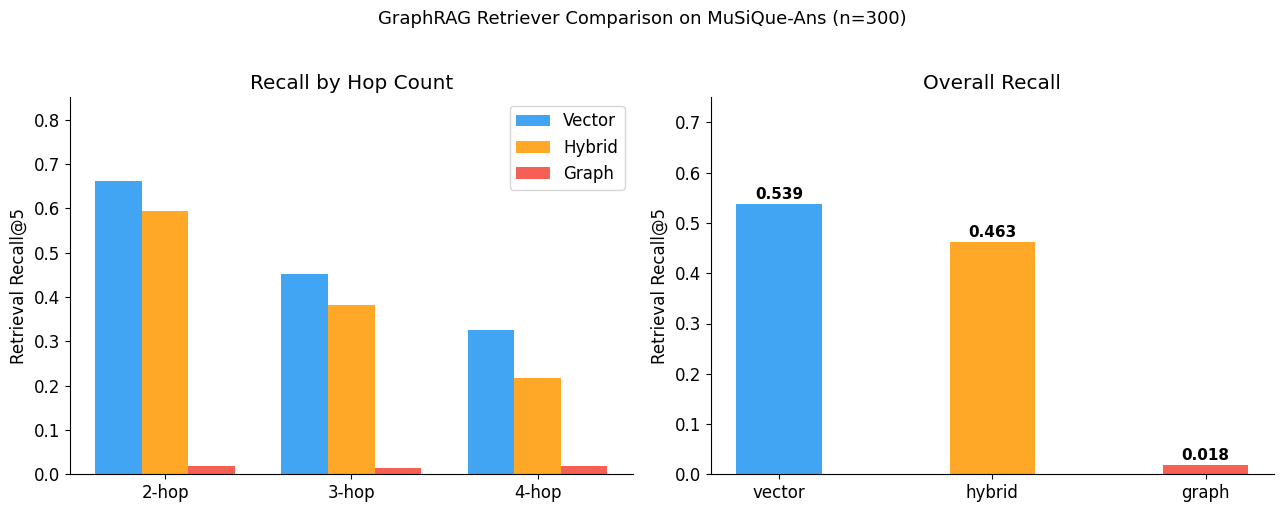

✅ Figure saved


In [18]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: recall by hop count (grouped bar) ───────────
ax = axes[0]
hops      = [2, 3, 4]
colors    = {"vector": "#2196F3", "hybrid": "#FF9800", "graph": "#F44336"}
width     = 0.25
x         = range(len(hops))

for i, ret in enumerate(["vector", "hybrid", "graph"]):
    vals = [pivot.loc[ret, h] for h in hops]
    ax.bar([xi + i*width for xi in x], vals, width,
           label=ret.capitalize(), color=colors[ret], alpha=0.85)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(["2-hop", "3-hop", "4-hop"])
ax.set_ylabel("Retrieval Recall@5")
ax.set_title("Recall by Hop Count")
ax.legend()
ax.set_ylim(0, 0.85)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# ── Right: overall recall bar ─────────────────────────
ax2 = axes[1]
retrievers = ["vector", "hybrid", "graph"]
overall    = [pivot.loc[r, "overall"] for r in retrievers]
bars = ax2.bar(retrievers, overall,
               color=[colors[r] for r in retrievers], alpha=0.85, width=0.4)
ax2.set_ylabel("Retrieval Recall@5")
ax2.set_title("Overall Recall")
ax2.set_ylim(0, 0.75)
for bar, val in zip(bars, overall):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

plt.suptitle("GraphRAG Retriever Comparison on MuSiQue-Ans (n=300)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/691FinalProject/results_recall.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure saved")

Winner distribution:
winner
vector    283
hybrid     16
graph       1
Name: count, dtype: int64

Vector wins 94.3% of questions

=== Router Classification Report ===
              precision    recall  f1-score   support

       graph       0.00      0.00      0.00         1
      hybrid       0.00      0.00      0.00         3
      vector       0.96      1.00      0.98        86

    accuracy                           0.96        90
   macro avg       0.32      0.33      0.33        90
weighted avg       0.91      0.96      0.93        90

=== Recall Comparison ===
Best single retriever : 0.539  (vector)
Adaptive router       : 0.548
Oracle upper bound    : 0.561
Router vs best-single : +0.010
Headroom captured     : 41.9%


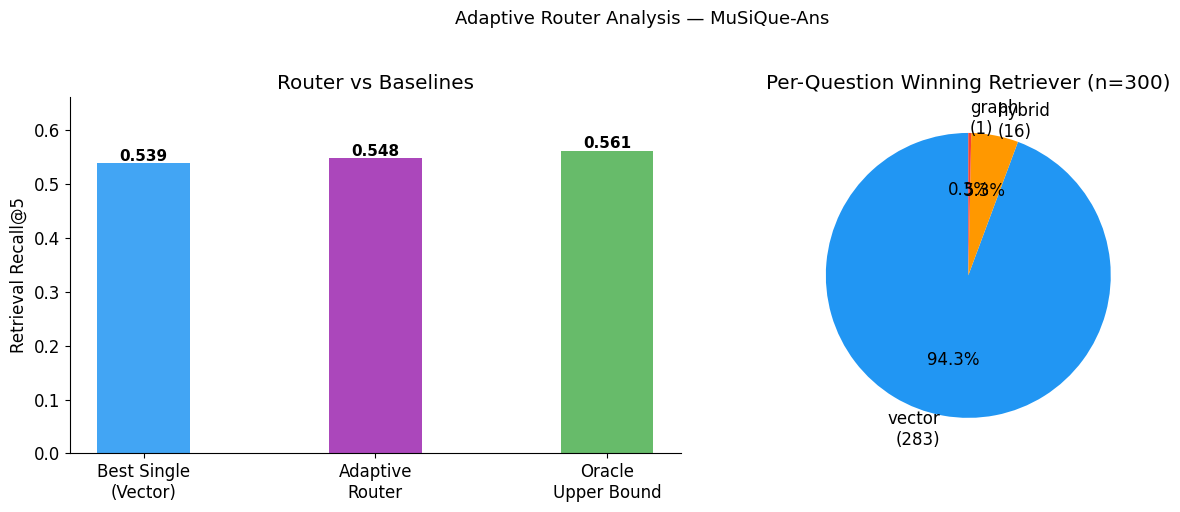

✅ Router figure saved


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import numpy as np

# ── Per-question winner labels ─────────────────────────
winner_rows = []
for qid, grp in df.groupby("qid"):
    recalls = grp.set_index("retriever")["recall"]
    winner  = recalls.idxmax()
    row     = grp.iloc[0]
    winner_rows.append({
        "qid":            qid,
        "hop_count":      row["hop_count"],
        "winner":         winner,
        "vec_recall":     recalls.get("vector", 0),
        "graph_recall":   recalls.get("graph",  0),
        "hybrid_recall":  recalls.get("hybrid", 0),
    })

wdf = pd.DataFrame(winner_rows)
print("Winner distribution:")
print(wdf["winner"].value_counts())
print(f"\nVector wins {(wdf['winner']=='vector').mean()*100:.1f}% of questions")

# ── Question features ──────────────────────────────────
def featurize(q: dict) -> list:
    text  = q["question"].lower()
    words = text.split()
    return [
        len(words),
        q["hop_count"],
        int(any(w in text for w in ["both","more","less","older","younger","taller","higher","longer"])),
        int(any(w in text for w in ["who","whom","whose"])),
        int(any(w in text for w in ["where","location","city","country","place"])),
        int(any(w in text for w in ["when","year","date","born","died"])),
        int(any(w in text for w in ["which","what"])),
        sum(1 for w in words if w[0].isupper() and len(w) > 1),
    ]

q_lookup = {q["id"]: q for q in sampled}
X = np.array([featurize(q_lookup[qid]) for qid in wdf["qid"]])
y = wdf["winner"].values

# ── Train / test split ─────────────────────────────────
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, list(range(len(wdf))), test_size=0.3, random_state=42
)

clf = LogisticRegression(max_iter=500, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\n=== Router Classification Report ===")
print(classification_report(y_test, y_pred, zero_division=0))

# ── Recall comparison ──────────────────────────────────
recall_col = {
    "vector": "vec_recall",
    "hybrid": "hybrid_recall",
    "graph":  "graph_recall"
}

oracle_recall = wdf[["vec_recall","hybrid_recall","graph_recall"]].max(axis=1).mean()
best_single   = wdf[["vec_recall","hybrid_recall","graph_recall"]].mean().max()

router_recall_vals = []
for i, idx in enumerate(idx_test):
    row = wdf.iloc[idx]
    router_recall_vals.append(row[recall_col[y_pred[i]]])
router_recall = np.mean(router_recall_vals)

gap = oracle_recall - best_single

print("=== Recall Comparison ===")
print(f"Best single retriever : {best_single:.3f}  (vector)")
print(f"Adaptive router       : {router_recall:.3f}")
print(f"Oracle upper bound    : {oracle_recall:.3f}")
print(f"Router vs best-single : {router_recall - best_single:+.3f}")
print(f"Headroom captured     : {(router_recall-best_single)/gap*100:.1f}%" if gap > 0 else "Headroom captured     : N/A (oracle ≈ best single)")

# ── Router figure ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: recall comparison bar
ax = axes[0]
labels = ["Best Single\n(Vector)", "Adaptive\nRouter", "Oracle\nUpper Bound"]
vals   = [best_single, router_recall, oracle_recall]
colors = ["#2196F3", "#9C27B0", "#4CAF50"]
bars   = ax.bar(labels, vals, color=colors, alpha=0.85, width=0.4)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Retrieval Recall@5")
ax.set_title("Router vs Baselines")
ax.set_ylim(0, max(vals) + 0.1)
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

# Right: winner distribution pie
ax2 = axes[1]
counts = wdf["winner"].value_counts()
colors_pie = {"vector": "#2196F3", "hybrid": "#FF9800", "graph": "#F44336"}
ax2.pie(
    counts.values,
    labels=[f"{k}\n({v})" for k, v in counts.items()],
    colors=[colors_pie[k] for k in counts.index],
    autopct="%1.1f%%",
    startangle=90
)
ax2.set_title("Per-Question Winning Retriever (n=300)")

plt.suptitle("Adaptive Router Analysis — MuSiQue-Ans", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/691FinalProject/results_router.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Router figure saved")

In [21]:
from openai import OpenAI
openai_client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

def generate_answer(question, retrieved):
    context = "\n\n".join(f"[{r['title']}]\n{r['text']}" for r in retrieved)
    prompt = f"""Answer using only the context. One short phrase.\n\nContext:\n{context}\n\nQuestion: {question}\nAnswer:"""
    try:
        resp = openai_client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=50, temperature=0)
        return resp.choices[0].message.content.strip()
    except Exception as e:
        return ""

# ── Stratified 50-question sample ─────────────────────
random.seed(99)
gen_sample = []
for hop in [2, 3, 4]:
    pool = [q for q in sampled if q["hop_count"] == hop]
    n    = {2: 25, 3: 15, 4: 10}[hop]
    gen_sample.extend(random.sample(pool, min(n, len(pool))))

print(f"Generation eval on {len(gen_sample)} questions")
print("Hop distribution:", {h: sum(1 for q in gen_sample if q["hop_count"]==h)
                            for h in [2,3,4]})
print("Estimated time: ~3-4 minutes\n")

# ── Eval loop ──────────────────────────────────────────
gen_rows = []
for q in tqdm(gen_sample, desc="Generating"):
    gold = q["answer"]
    for name, fn in [
        ("vector", vector_retrieve),
        ("graph",  graph_retrieve_fast),
        ("hybrid", hybrid_retrieve_fast),
    ]:
        retrieved = fn(q["question"])
        pred      = generate_answer(q["question"], retrieved)
        time.sleep(2)   # Groq is generous but let's be safe

        em = exact_match(pred, gold)
        f1 = token_f1(pred, gold)

        gen_rows.append({
            "qid":       q["id"],
            "hop_count": q["hop_count"],
            "retriever": name,
            "gold":      gold,
            "pred":      pred,
            "em":        em,
            "f1":        f1,
        })

gen_df = pd.DataFrame(gen_rows)

# ── Results tables ─────────────────────────────────────
print("\n=== Exact Match by Retriever × Hop Count ===")
em_pivot = gen_df.groupby(["retriever","hop_count"])["em"].mean().unstack()
em_pivot["overall"] = gen_df.groupby("retriever")["em"].mean()
print(em_pivot.round(3).to_string())

print("\n=== Token F1 by Retriever × Hop Count ===")
f1_pivot = gen_df.groupby(["retriever","hop_count"])["f1"].mean().unstack()
f1_pivot["overall"] = gen_df.groupby("retriever")["f1"].mean()
print(f1_pivot.round(3).to_string())

# Save
gen_df.to_csv("/content/drive/MyDrive/691FinalProject/gen_results.csv", index=False)
print("\n Saved to Drive")

Generation eval on 50 questions
Hop distribution: {2: 25, 3: 15, 4: 10}
Estimated time: ~3-4 minutes



Generating: 100%|██████████| 50/50 [07:00<00:00,  8.41s/it]


=== Exact Match by Retriever × Hop Count ===
hop_count     2      3    4  overall
retriever                           
graph      0.00  0.067  0.0     0.02
hybrid     0.08  0.133  0.1     0.10
vector     0.16  0.133  0.1     0.14

=== Token F1 by Retriever × Hop Count ===
hop_count      2      3     4  overall
retriever                             
graph      0.000  0.104  0.05    0.041
hybrid     0.164  0.204  0.23    0.189
vector     0.264  0.185  0.15    0.218

 Saved to Drive


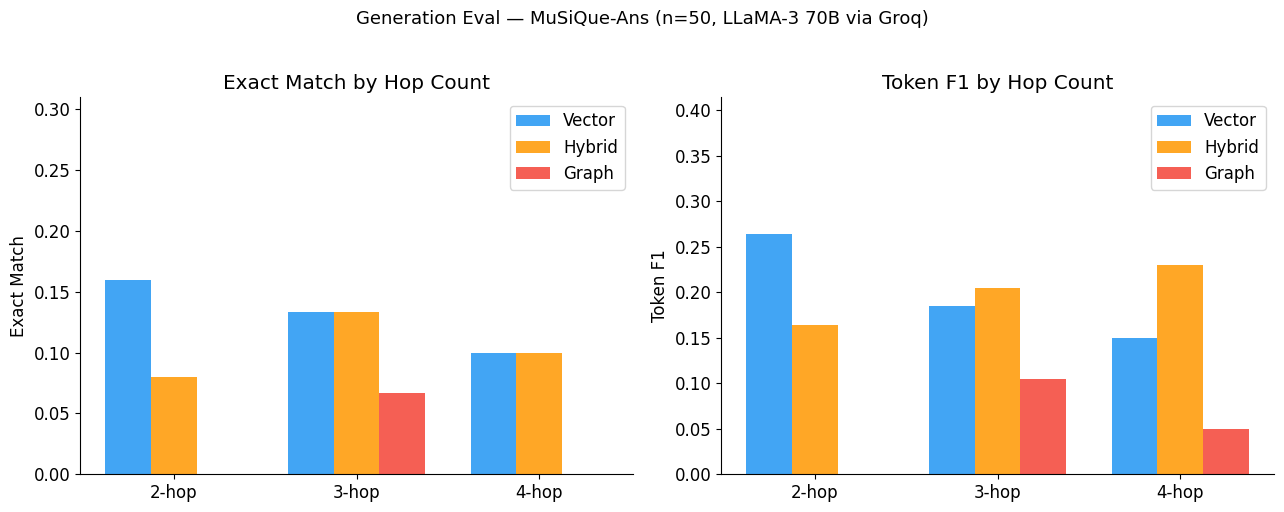

 Generation figure saved


In [22]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"vector": "#2196F3", "hybrid": "#FF9800", "graph": "#F44336"}

for ax, (pivot, title) in zip(axes, [
    (em_pivot, "Exact Match"),
    (f1_pivot, "Token F1"),
]):
    hops  = [h for h in [2, 3, 4] if h in pivot.columns]
    width = 0.25
    x     = range(len(hops))

    for i, ret in enumerate(["vector", "hybrid", "graph"]):
        if ret not in pivot.index:
            continue
        vals = [pivot.loc[ret, h] for h in hops]
        ax.bar([xi + i*width for xi in x], vals, width,
               label=ret.capitalize(), color=colors[ret], alpha=0.85)

    ax.set_xticks([xi + width for xi in x])
    ax.set_xticklabels([f"{h}-hop" for h in hops])
    ax.set_ylabel(title)
    ax.set_title(f"{title} by Hop Count")
    ax.legend()
    ax.set_ylim(0, max(pivot[hops].max()) + 0.15)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.suptitle("Generation Eval — MuSiQue-Ans (n=50, LLaMA-3 70B via Groq)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/691FinalProject/results_generation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(" Generation figure saved")